# Pipeline model visualization

Compare the cross-validated leakage predictions from M1, M2, M3, and M4. M1 is position-independent; M2, M3, and M4 are evaluated separately at each of the final 16 prompt positions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'outputs').exists())
OUTPUT_DIR = ROOT / 'outputs' / 'pipeline'

m1_metrics = pd.read_csv(OUTPUT_DIR / 'M1_metrics.csv')
multitoken_metrics = pd.read_csv(OUTPUT_DIR / 'multitoken_metrics.csv')
m3_metrics = pd.read_csv(OUTPUT_DIR / 'M3_model_comparison_metrics.csv')

print('Loaded metrics from outputs/pipeline')

Loaded metrics from outputs/pipeline


## Mean grouped-fold ROC-AUC by prompt position

M2 uses Top-k/SVD features, M3 averages M1-LogReg and M2 probabilities, and M4 combines Top-k/SVD with the four secret-rank features. The control-only fold has one class, so its ROC-AUC is undefined and excluded from the fold mean.

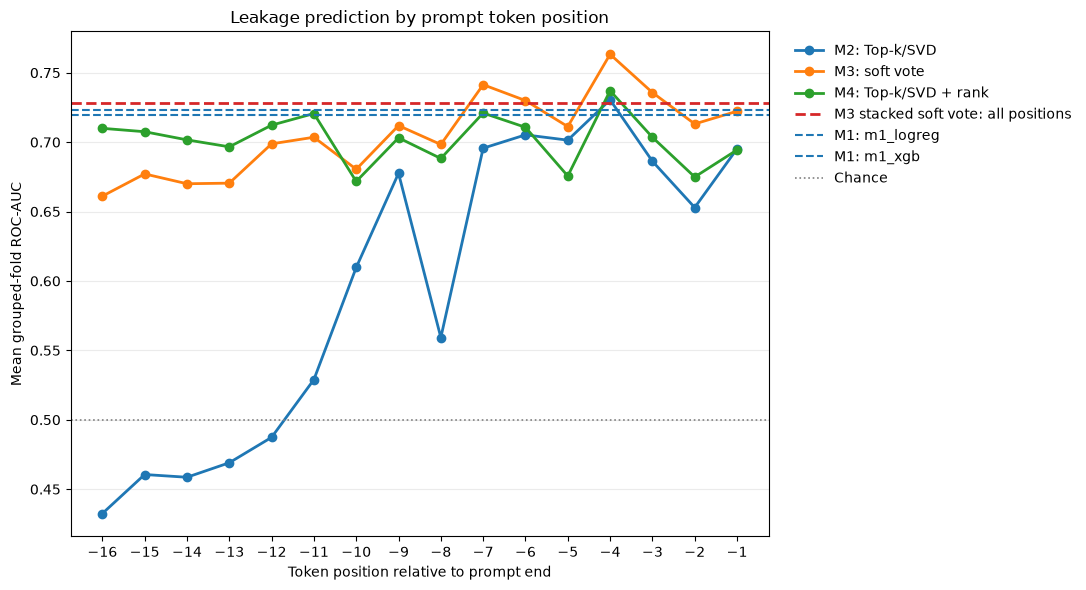

In [2]:
m2 = multitoken_metrics[multitoken_metrics['feature_mode'].eq('topk_only')].copy()
m2['model'] = 'M2: Top-k/SVD'

m4 = multitoken_metrics[multitoken_metrics['feature_mode'].eq('topk_plus_rank')].copy()
m4['model'] = 'M4: Top-k/SVD + rank'

m3 = m3_metrics[m3_metrics['model'].eq('m3_soft_vote')].copy()
m3['model'] = 'M3: soft vote'
m3_stacked = m3_metrics.loc[m3_metrics['model'].eq('m3_stacked_soft_vote')].iloc[0]

position_metrics = pd.concat([m2, m3, m4], ignore_index=True)
position_metrics['position_from_end'] = -position_metrics['position'].str.rsplit('_', n=1).str[-1].astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
for model, subset in position_metrics.groupby('model', sort=False):
    subset = subset.sort_values('position_from_end')
    ax.plot(subset['position_from_end'], subset['mean_fold_auc'], marker='o', linewidth=2, label=model)

ax.axhline(
    m3_stacked['mean_fold_auc'], color='C3', linestyle='--', linewidth=2,
    label='M3 stacked soft vote: all positions',
)
for _, row in m1_metrics.iterrows():
    ax.axhline(row['mean_fold_auc'], linestyle='--', linewidth=1.5, label=f"M1: {row['model']}")
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, label='Chance')
ax.set(
    xlabel='Token position relative to prompt end',
    ylabel='Mean grouped-fold ROC-AUC',
    title='Leakage prediction by prompt token position',
)
ax.set_xticks(range(-16, 0))
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

## OOF accuracy by prompt position

Accuracy uses the fixed 0.5 probability threshold. The majority baseline always predicts the more frequent development label.

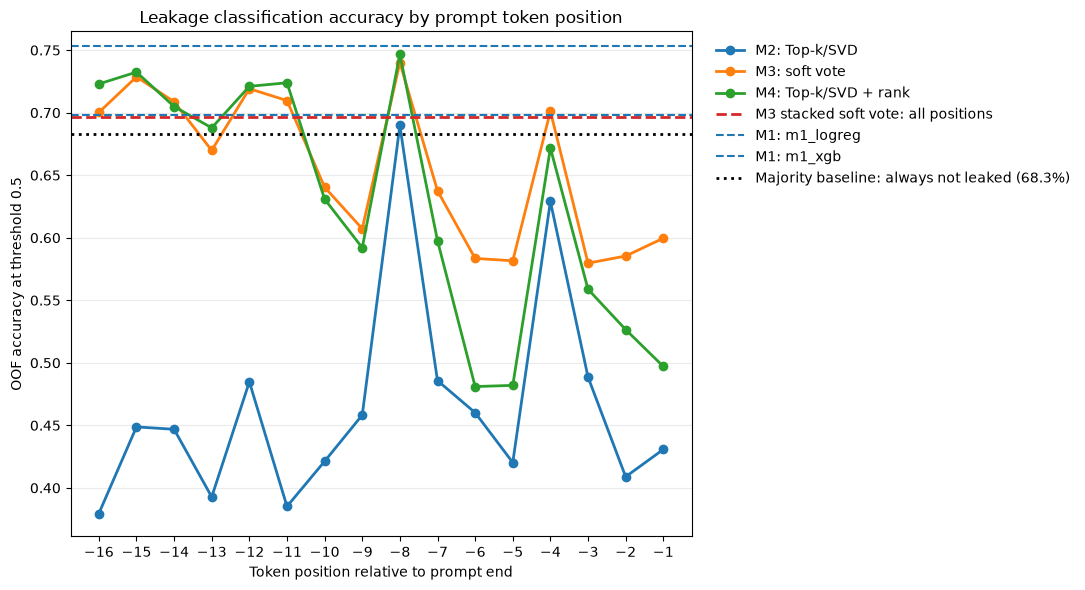

Majority baseline: always not leaked = 0.683 accuracy (720/1054 not leaked)


In [3]:
n_dev = int(m1_metrics['n_dev'].iloc[0])
n_leaks = int(m1_metrics['n_leaks'].iloc[0])
n_not_leaked = n_dev - n_leaks
majority_label = 'not leaked' if n_not_leaked >= n_leaks else 'leaked'
majority_accuracy = max(n_not_leaked, n_leaks) / n_dev

fig, ax = plt.subplots(figsize=(11, 6))
for model, subset in position_metrics.groupby('model', sort=False):
    subset = subset.sort_values('position_from_end')
    ax.plot(subset['position_from_end'], subset['oof_accuracy'], marker='o', linewidth=2, label=model)

ax.axhline(
    m3_stacked['oof_accuracy'], color='C3', linestyle='--', linewidth=2,
    label='M3 stacked soft vote: all positions',
)
for _, row in m1_metrics.iterrows():
    ax.axhline(row['oof_accuracy'], linestyle='--', linewidth=1.5, label=f"M1: {row['model']}")
ax.axhline(
    majority_accuracy, color='black', linestyle=':', linewidth=2,
    label=f'Majority baseline: always {majority_label} ({majority_accuracy:.1%})',
)
ax.set(
    xlabel='Token position relative to prompt end',
    ylabel='OOF accuracy at threshold 0.5',
    title='Leakage classification accuracy by prompt token position',
)
ax.set_xticks(range(-16, 0))
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()
print(f'Majority baseline: always {majority_label} = {majority_accuracy:.3f} accuracy ({n_not_leaked}/{n_dev} not leaked)')

## Confusion matrices for the best version of M1–M4

Each matrix uses development OOF predictions at threshold 0.5. The M2–M4 position is selected by mean grouped-fold ROC-AUC; M1 uses its better classifier variant and is position-independent.

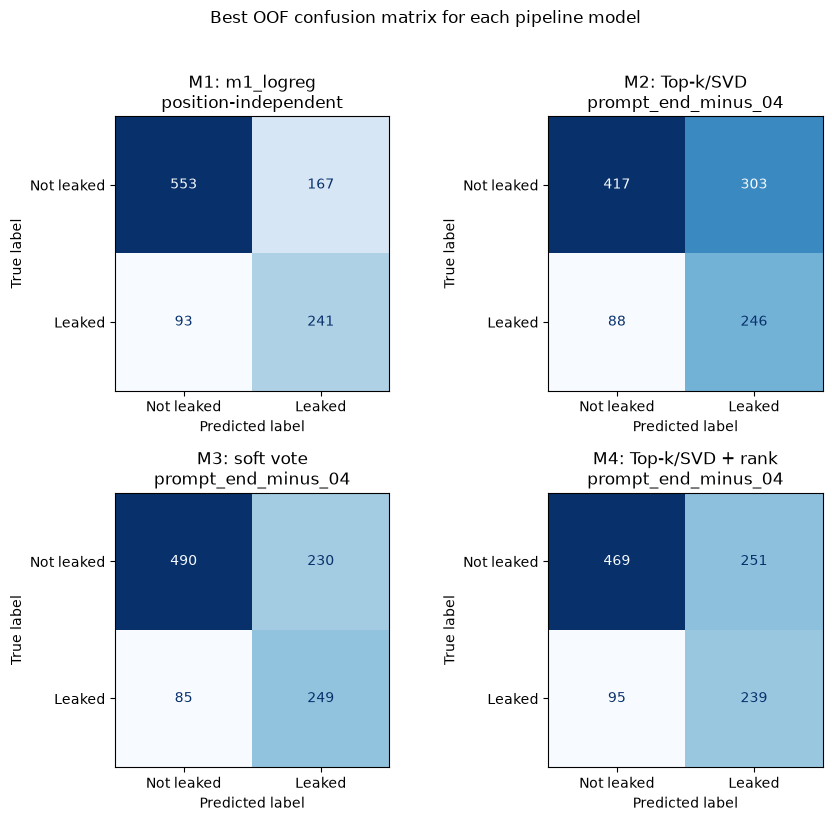

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

m1_predictions = pd.read_csv(OUTPUT_DIR / 'M1_predictions.csv')
m2_m4_predictions = pd.read_csv(OUTPUT_DIR / 'multitoken_predictions.csv')
m3_predictions = pd.read_csv(OUTPUT_DIR / 'M3_soft_voting_predictions.csv')

m1_best = m1_metrics.loc[m1_metrics['mean_fold_auc'].idxmax()]
m2_best = m2.loc[m2['mean_fold_auc'].idxmax()]
m3_best = m3.loc[m3['mean_fold_auc'].idxmax()]
m4_best = m4.loc[m4['mean_fold_auc'].idxmax()]

dev = m1_predictions['split'].eq('dev')
actual = m1_predictions.loc[dev, 'attack_successful'].astype(bool)
assert m1_predictions.loc[dev, 'run_id'].reset_index(drop=True).equals(
    m2_m4_predictions.loc[m2_m4_predictions['split'].eq('dev'), 'run_id'].reset_index(drop=True)
)
assert m1_predictions.loc[dev, 'run_id'].reset_index(drop=True).equals(
    m3_predictions.loc[m3_predictions['split'].eq('dev'), 'run_id'].reset_index(drop=True)
)

best_predictions = {
    f"M1: {m1_best['model']}\nposition-independent": (
        m1_predictions.loc[dev, f"{m1_best['model']}_predicted_leaked"].astype(bool)
    ),
    f"M2: Top-k/SVD\n{m2_best['position']}": (
        m2_m4_predictions.loc[dev, f"topk_only__{m2_best['position']}__predicted_leaked"].astype(bool)
    ),
    f"M3: soft vote\n{m3_best['position']}": (
        m3_predictions.loc[dev, f"m3__{m3_best['position']}__predicted_leaked"].astype(bool)
    ),
    f"M4: Top-k/SVD + rank\n{m4_best['position']}": (
        m2_m4_predictions.loc[dev, f"topk_plus_rank__{m4_best['position']}__predicted_leaked"].astype(bool)
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (title, predicted) in zip(axes.ravel(), best_predictions.items()):
    matrix = confusion_matrix(actual, predicted, labels=[False, True])
    ConfusionMatrixDisplay(matrix, display_labels=['Not leaked', 'Leaked']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_title(title)
fig.suptitle('Best OOF confusion matrix for each pipeline model', y=1.02)
fig.tight_layout()
plt.show()

## Best development ROC-AUC for each model

,model,position,mean_fold_auc,fold_auc_std,oof_auc,oof_accuracy,oof_balanced_accuracy
3,M3: soft vote,prompt_end_minus_04,0.763,0.039,0.802,0.701,0.713
4,M4: Top-k/SVD + rank,prompt_end_minus_04,0.737,0.069,0.762,0.672,0.683
2,M2: Top-k/SVD,prompt_end_minus_04,0.730,0.074,0.714,0.629,0.658
0,M1: m1_logreg,position-independent,0.723,0.028,0.801,0.753,0.745
1,M1: m1_xgb,position-independent,0.719,0.029,0.767,0.698,0.713


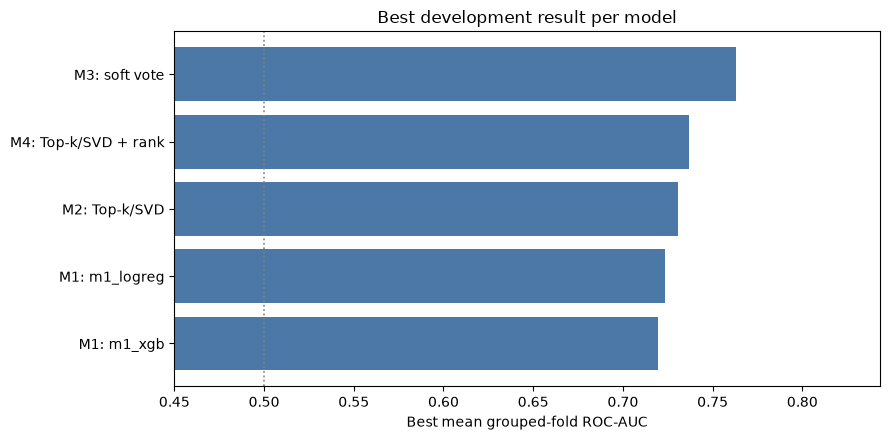

In [5]:
best_position_models = (
    position_metrics.loc[position_metrics.groupby('model')['mean_fold_auc'].idxmax()]
    [['model', 'position', 'mean_fold_auc', 'fold_auc_std', 'oof_auc', 'oof_accuracy', 'oof_balanced_accuracy']]
)
best_m1 = m1_metrics.rename(columns={'model': 'variant'}).copy()
best_m1['model'] = 'M1: ' + best_m1['variant']
best_m1['position'] = 'position-independent'
best_m1 = best_m1[['model', 'position', 'mean_fold_auc', 'fold_auc_std', 'oof_auc', 'oof_accuracy', 'oof_balanced_accuracy']]
best_models = pd.concat([best_m1, best_position_models], ignore_index=True).sort_values('mean_fold_auc', ascending=False)
display(best_models.style.format({
    'mean_fold_auc': '{:.3f}',
    'fold_auc_std': '{:.3f}',
    'oof_auc': '{:.3f}',
    'oof_accuracy': '{:.3f}',
    'oof_balanced_accuracy': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(9, 4.5))
ordered = best_models.sort_values('mean_fold_auc')
ax.barh(ordered['model'], ordered['mean_fold_auc'], color='#4C78A8')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.2)
ax.set(xlabel='Best mean grouped-fold ROC-AUC', title='Best development result per model')
ax.set_xlim(0.45, min(1.0, ordered['mean_fold_auc'].max() + 0.08))
fig.tight_layout()
plt.show()

## Output files

The prediction CSVs contain one row per run. M2/M4 and M3 provide one probability column per prompt position; M1 provides one probability per classifier variant.

In [6]:
for filename in [
    'M1_predictions.csv',
    'multitoken_predictions.csv',
    'M3_soft_voting_predictions.csv',
]:
    path = OUTPUT_DIR / filename
    table = pd.read_csv(path, nrows=1)
    probability_columns = [column for column in table if column.endswith('probability')]
    print(f'{filename}: {len(probability_columns)} probability columns')

M1_predictions.csv: 2 probability columns
multitoken_predictions.csv: 34 probability columns
M3_soft_voting_predictions.csv: 35 probability columns
